# Inference Notebook
Used to mask a random image from the dataset and try to reconstruct it with weights of the training. 

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
import torch
import os
import glob
import cv2
import random
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
from safetensors import safe_open
from albumentations.pytorch import ToTensorV2
from local_datasets.terramesh import Transpose, MultimodalTransforms, MultimodalNormalize, statistics
from utils.utils import load_specs, build_urls, compute_wavelength_stats
from utils.masking import generate_mask
from local_datasets.terramesh_dataset import TerraMeshDataset
from virtues.modules.multiplex_virtues import TerraMeshViT
#from virtues.modules.terramesh_virtues import TerraMeshViT

/home/corentinS/.conda/envs/pds_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Paths
PATH_TO_WEIGHTS = "../experiments/final_train_losses_eval/checkpoints/checkpoint-84780" # Path to the checkpoint to load for inference
PATH_DATASET = "../../../data/corentin/data/TerraMesh/train"
PATH_L8_ROOT = "../../../data/corentin/data/images/L8/npy/"
modalities =  ["S2L2A", "S1RTC"]
PATH_SENSORS_SPECS = './spectrum/pretraining_sensors.yaml' # Path to sensors specs file
PATH_SPECTRUM_SPECS = './spectrum/electromagnetic_spectrum.yaml' # Path to spectrum specs file

### **1. Dataset Initialization**

In [4]:
# Load the sensor and spectrum specifications
sensors = [1, 2]  # Example sensor IDs

sensor_specs, spectrum_specs = load_specs(PATH_SENSORS_SPECS, PATH_SPECTRUM_SPECS)
# Filter the sensor and spectrum specs to only include the sensors specified in the config
sensor_specs = {k: v for k, v in sensor_specs.items() if v['sensor_idx'] in sensors}

# Build remap from old ids to contiguous [0..N-1]
selected_old_ids = sorted({v["sensor_idx"] for v in sensor_specs.values()})
old_to_new = {old_id: new_id for new_id, old_id in enumerate(selected_old_ids)}

# Apply remap in-place (or on a copied dict)
for k in sensor_specs:
    sensor_specs[k]["sensor_idx"] = old_to_new[sensor_specs[k]["sensor_idx"]]

num_sensors = len(sensor_specs)
print(f"number of sensors: {num_sensors}")

number of sensors: 2


In [5]:
val_transforms = MultimodalTransforms(
        transforms=A.Compose([
            Transpose([1, 2, 0]),  # Convert data to channel last (expected shape from albumentations)
            MultimodalNormalize(mean=statistics["mean"], std=statistics["std"]),
            A.CenterCrop(224, 224),
            ToTensorV2(),  # Convert to tensor and back to channel first
        ],
            is_check_shapes=False,  # Not needed because of aligned data in TerraMesh
            additional_targets={m: "image" for m in modalities}  
        ),
        non_image_modalities=["__key__", "__url__"],  # Additional non-image keys
    )


We will use a different shard from the training and validation split to have new images

In [6]:
all_shard_names = sorted([
    os.path.basename(s) 
    for s in glob.glob(os.path.join(PATH_DATASET, modalities[0], "*.tar"))
    if "majortom" in os.path.basename(s)  # ← only keep majortom shards
    ])
shard_name = all_shard_names[0]
print(f"DEBUG: First shard name: {shard_name}")

val_urls = build_urls(PATH_DATASET, modalities, shard_names=[shard_name])

test_dataset = TerraMeshDataset(
    #path=conf.dataset_path,
    urls=val_urls,
    modalities=modalities,
    sensor_specs=sensor_specs,
    spectrum_specs=spectrum_specs,
    shuffle=False,  # No shuffling for validation/test
    #split= "val",
    transform=val_transforms,
    seed=42,
    batch_size=8,
    patch_size=16,
    masking_ratio= (0.6, 1)
)


DEBUG: First shard name: majortom_shard_000001.tar


### **2. Visualization**
Vizualization of the original image using IRRG pseudo-coloring for Sentinel-2 L2A images and using a dB scale as VH-VV-VV/VH for Sentinel-1 RTC images.

In [7]:
it = iter(test_dataset)        # run once


In [8]:
batch = next(it)               # re-run this cell to get the next batch

In [9]:
# Get one batch
images, channel_indices, masks, sensor_indices, proj_indices = batch
# images: [B, C, H, W]
# Pick a random item from the batch
b = 2
print(f"Visualizing sample {b} from the batch")

img = images[b]  # [C, H, W]
C, H, W = img.shape
patch_size = 16

mask = masks[b]  # [num_patches]
channel_idx = channel_indices[b]  # [C]
sensor_idx = sensor_indices[b]  # [C]
proj_idx = proj_indices[b]  # [C]

print("channel_idx range:", channel_idx.min().item(), channel_idx.max().item())
print("sensor_idx range:", sensor_idx.min().item(), sensor_idx.max().item())
print("proj_idx range:", proj_idx.min().item(), proj_idx.max().item())

# S2L2A has 12 bands (first channels), pick RGB = bands 3,2,1 (0-indexed)
rgb = img[[3, 2, 1]]                          # [3, H, W], normalized
mean = torch.tensor(statistics["mean"]["S2L2A"])[[3, 2, 1]].view(-1, 1, 1)
std  = torch.tensor(statistics["std"]["S2L2A"])[[3, 2, 1]].view(-1, 1, 1)
rgb = (rgb * std + mean).permute(1, 2, 0).numpy()   # [H, W, 3], original scale


# Sentinel-1 has 2 bands (VV, VH)
s1rtc = img[11:13] 

Visualizing sample 2 from the batch
channel_idx range: 0 13
sensor_idx range: 0 1
proj_idx range: 0 16


In [10]:
# util function to enhance contrast for better visualization
# from Terramesh paper supp mat
def transform_rgb(rbg):
    Q2, Q98 = np.quantile(rbg, [0.02, 0.98])
    rbg = np.where(rbg >= Q2, rbg, Q2 + (rbg - Q2) * 0.5)
    rbg = np.where(rbg <= Q98, rbg, Q98 + (rbg - Q98) * 0.5)
    Q02, Q50, Q998 = np.quantile(rbg,[0.002, 0.5, 0.998])
    U = max(2000, Q998)
    L = 0 if Q50 < 1000 else Q02
    rbg = (rbg - L) / (U - L) * 255
    rbg = np.clip(rbg, 0, 255)
    
    return rbg.astype(np.uint8)

In [11]:
rgb_vis = transform_rgb(rgb)

In [12]:
# 1. Denormalize → back to original scale (log)
mean = torch.tensor(statistics["mean"]["S1RTC"]).view(-1, 1, 1)
std  = torch.tensor(statistics["std"]["S1RTC"]).view(-1, 1, 1)
s1rtc_denorm = s1rtc * std + mean  # [C, H, W]

# 2. Light speckle filter
vh = s1rtc_denorm[1]
vv = s1rtc_denorm[0]

# 3. Ratio in log space (VH/VV) = VH - VV in dB
ratio = vh - vv

# 4. Clip to typical SAR dB ranges before display
vv_display = np.clip(vv, -25, 0)
vh_display = np.clip(vh, -30, -5)
ratio_display = np.clip(ratio, -15, 5)

# 5. Normalize each to [0, 1] for imshow
def to_uint8(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

R = to_uint8(vh_display)
G = to_uint8(vv_display)
B = to_uint8(ratio_display)
s1_rgb = np.stack([R, G, B], axis=-1)

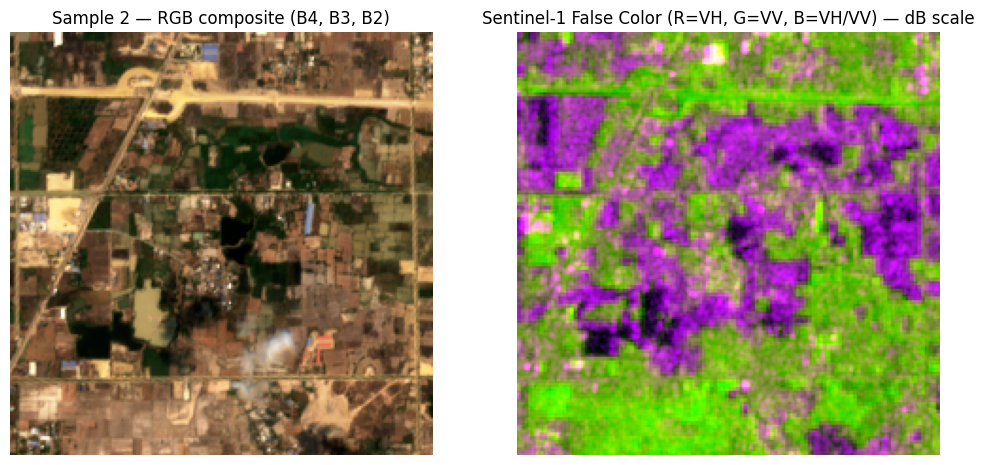

In [13]:
# Plot the two modalities side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(rgb_vis)
axs[0].set_title(f"Sample {b} — RGB composite (B4, B3, B2)")
axs[0].axis("off")
axs[1].imshow(s1_rgb)
axs[1].set_title('Sentinel-1 False Color (R=VH, G=VV, B=VH/VV) — dB scale')
axs[1].axis("off")
plt.show()

### **3. Models Initialization**
We load here the weights of the model with the different pretraining tested. 

In [14]:
conf = OmegaConf.load('./virtues/configs/base_config.yaml')


In [15]:
# print the bands for the plotted sample
print("Bands in the plotted sample:")
for c in range(img.shape[0]):
    ch_idx = channel_idx[c].item()
    sensor_id = sensor_idx[c].item()
    # Find the sensor name corresponding to this sensor_id
    sensor_name = None
    for name, spec in sensor_specs.items():
        if spec["sensor_idx"] == sensor_id:
            sensor_name = name
            break
    print(f"Channel {c}: Sensor {sensor_name} (ID {sensor_id}), Band index {ch_idx}")

Bands in the plotted sample:
Channel 0: Sensor SENTINEL2-L2A (ID 0), Band index 0
Channel 1: Sensor SENTINEL2-L2A (ID 0), Band index 1
Channel 2: Sensor SENTINEL2-L2A (ID 0), Band index 2
Channel 3: Sensor SENTINEL2-L2A (ID 0), Band index 3
Channel 4: Sensor SENTINEL2-L2A (ID 0), Band index 4
Channel 5: Sensor SENTINEL2-L2A (ID 0), Band index 5
Channel 6: Sensor SENTINEL2-L2A (ID 0), Band index 6
Channel 7: Sensor SENTINEL2-L2A (ID 0), Band index 7
Channel 8: Sensor SENTINEL2-L2A (ID 0), Band index 8
Channel 9: Sensor SENTINEL2-L2A (ID 0), Band index 9
Channel 10: Sensor SENTINEL2-L2A (ID 0), Band index 10
Channel 11: Sensor SENTINEL2-L2A (ID 0), Band index 11
Channel 12: Sensor SENTINEL1-RTC (ID 1), Band index 12
Channel 13: Sensor SENTINEL1-RTC (ID 1), Band index 13


In [16]:
_full_sensor_specs, _ = load_specs(PATH_SENSORS_SPECS, PATH_SPECTRUM_SPECS)
sensor_specs_model = {
    k: v for k, v in _full_sensor_specs.items()
    if v['sensor_idx'] in [1, 2, 3]
}
wavelengths_per_proj, polarization_per_proj, log_wl_mean = compute_wavelength_stats(
    sensor_specs_model, spectrum_specs
)
print(f"wavelengths_per_proj length: {wavelengths_per_proj.shape[0]} (valid indices 0..{wavelengths_per_proj.shape[0]-1})")

wavelengths_per_proj length: 19 (valid indices 0..18)


In [17]:
# Model initialization
model = TerraMeshViT(
        use_default_config = False,
        custom_config = None,
        sensor_specs=sensor_specs,
        spectrum_specs=spectrum_specs,
        num_sensors=num_sensors,
        prior_bias_embedding_type='wl',
        prior_bias_embedding_fusion_type='concatenate',
        patch_size=conf.model.patch_size,
        model_dim=conf.model.model_dim,
        feedforward_dim=conf.model.feedforward_dim,
        encoder_pattern=conf.model.encoder_pattern,
        num_encoder_heads=conf.model.num_encoder_heads,
        decoder_pattern=conf.model.decoder_pattern,
        num_decoder_heads=conf.model.num_decoder_heads,
        num_hidden_layers=conf.model.num_decoder_hidden_layers,
        positional_embedding_type=conf.model.positional_embedding_type,
        dropout=conf.model.dropout,
        group_layers=conf.model.group_layers,
        norm_after_encoder_decoder=conf.model.norm_after_encoder_decoder,
        verbose=False
    )

We provide the weights of the pretrained VirTues instance

In [18]:
# Load the checkpoint saved locally
weights = {}
with safe_open(os.path.join(PATH_TO_WEIGHTS , "model.safetensors"), framework="pt", device="cpu") as f:
    for k in f.keys():
        weights[k] = f.get_tensor(k)

model.load_state_dict(weights)
model = model.cuda().eval()

### **4. Tests**

Before evaluating our model, we will perform some tests to ensure that everything run smoothly. 

In [19]:
# Prepare inputs for the model
# Move all to CUDA
img        = img.cuda()     # or however you batch
channel_idx = channel_idx.cuda().long()  # Ensure indices are long tensors
mask        = mask.cuda()
sensor_idx  = sensor_idx.cuda().long()
proj_idx    = proj_idx.cuda().long() 

# print shape and stats for debugging
print("Input shapes:")
print("img shape       :", img.shape)
print("channel_idx shape:", channel_idx.shape)
print("mask shape       :", mask.shape)
print("sensor_idx shape :", sensor_idx.shape)
print("proj_idx shape   :", proj_idx.shape)

Input shapes:
img shape       : torch.Size([14, 224, 224])
channel_idx shape: torch.Size([14])
mask shape       : torch.Size([14, 14, 14])
sensor_idx shape : torch.Size([14])
proj_idx shape   : torch.Size([14, 14, 14])


In [20]:
# Util function to compute Pearson correlation between two tensors
def pearson_correlation(a, b):
    a_flat = a.flatten()
    b_flat = b.flatten()
    a_centered = a_flat - a_flat.mean()
    b_centered = b_flat - b_flat.mean()
    return (a_centered * b_centered).sum() / (
        torch.sqrt((a_centered ** 2).sum()) * torch.sqrt((b_centered ** 2).sum()) + 1e-8
    )

In [21]:
# Util function to create a mask that masks an entire channel or a list of channels
def generate_channel_mask(C, H, W, p, channels):
    # one full channel completely masked
    mask = torch.zeros(C, H // p, W // p, dtype=torch.bool)
    mask[channels] = True   # advanced indexing handles both int and list
    return mask


#### **4.1 Encoder-Decoder reconstruction without masking**

In [22]:

output_no_mask = model(
    multiplex=[img],  # whatever your input shape is
    channel_ids=[channel_idx],
    multiplex_mask=None,        
    projection_indices=[proj_idx],
)
recon_no_mask = output_no_mask.decoded_multiplex[0]

# Compare to original input
for band_idx in range(img.shape[0]):
    mse = torch.mean((recon_no_mask[band_idx] - img[band_idx]) ** 2).item()
    pearson = pearson_correlation(recon_no_mask[band_idx], img[band_idx]).item()
    mean_recon = recon_no_mask[band_idx].mean().item()
    mean_gt = img[band_idx].mean().item()
    print(f"Band {band_idx}: MSE={mse:.4f}, Pearson={pearson:.4f}, "
          f"mean recon={mean_recon:.4f}, mean gt={mean_gt:.4f}")

Band 0: MSE=0.0006, Pearson=0.9856, mean recon=-0.2048, mean gt=-0.2051
Band 1: MSE=0.0021, Pearson=0.9784, mean recon=-0.1780, mean gt=-0.1785
Band 2: MSE=0.0032, Pearson=0.9819, mean recon=-0.0790, mean gt=-0.0794
Band 3: MSE=0.0046, Pearson=0.9847, mean recon=0.0110, mean gt=0.0101
Band 4: MSE=0.0048, Pearson=0.9833, mean recon=0.0575, mean gt=0.0592
Band 5: MSE=0.0054, Pearson=0.9821, mean recon=-0.0539, mean gt=-0.0506
Band 6: MSE=0.0063, Pearson=0.9819, mean recon=-0.0502, mean gt=-0.0457
Band 7: MSE=0.0049, Pearson=0.9869, mean recon=-0.1159, mean gt=-0.1129
Band 8: MSE=0.0075, Pearson=0.9837, mean recon=-0.0237, mean gt=-0.0208
Band 9: MSE=0.0039, Pearson=0.9873, mean recon=-0.0502, mean gt=-0.0483
Band 10: MSE=0.0174, Pearson=0.9907, mean recon=0.7221, mean gt=0.7207
Band 11: MSE=0.0169, Pearson=0.9899, mean recon=0.6188, mean gt=0.6185
Band 12: MSE=0.0173, Pearson=0.9880, mean recon=0.0697, mean gt=0.0723
Band 13: MSE=0.0172, Pearson=0.9861, mean recon=0.0158, mean gt=0.0158


#### **4.3 Pick representative pairs**

We will perform a pearson correlation test between the following bands for both models:
- Adjacent: 4 (red_edge_1) and 5 (red_edge_2) 
- Close: 2 (green) and 5 (red_edge_2)
- Distant: 0 (aerosol) and 11 (swir_2)
- SAR: 12 (sar_vv) and 13 (sar_vh) — polarization test  

In [ ]:
def two_band_masking_test(model, img, band_a_idx, band_b_idx, channel_idx, sensor_idx, proj_idx):
    # Mask both band_a and band_b fully
    mask = generate_channel_mask(C, H, W, patch_size, channels=[band_a_idx, band_b_idx]).cuda()
    
    # Run forward pass
    # Perform a forward pass with the new mask
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda'):
            output = model.forward(
                multiplex=[img],
                channel_ids=[channel_idx],
                multiplex_mask=[mask],
                sensor_ids=[sensor_idx],
                projection_indices=[proj_idx],
            )
    recon = output.decoded_multiplex[0]
    
    recon_a = recon[band_a_idx]
    recon_b = recon[band_b_idx]
    gt_a = img[band_a_idx]
    gt_b = img[band_b_idx]
    
    mse_a_to_a = torch.mean((recon_a - gt_a) ** 2).item()
    mse_a_to_b = torch.mean((recon_a - gt_b) ** 2).item()
    mse_b_to_a = torch.mean((recon_b - gt_a) ** 2).item()
    mse_b_to_b = torch.mean((recon_b - gt_b) ** 2).item()
    
    pearson_a_to_a = pearson_correlation(recon_a, gt_a)
    pearson_b_to_b = pearson_correlation(recon_b, gt_b)
    
    # Decision criteria
    # keep zero shot mse 
    a_correctly_identified = mse_a_to_a < mse_a_to_b
    b_correctly_identified = mse_b_to_b < mse_b_to_a
    
    return {
        'mse_a_to_a': mse_a_to_a, 'mse_a_to_b': mse_a_to_b,
        'mse_b_to_a': mse_b_to_a, 'mse_b_to_b': mse_b_to_b,
        'pearson_a': pearson_a_to_a, 'pearson_b': pearson_b_to_b,
        'a_correct': a_correctly_identified, 'b_correct': b_correctly_identified,
    }

In [ ]:
N_BATCHES = 15  # number of batches to evaluate over

pairs = [
    ('adjacent (red_edge_1, red_edge_2)', (4, 5)),
    ('close (green, red_edge_2)', (2, 5)),
    ('distant (aerosol, swir_2)', (0, 11)),
    ('sar (vv, vh)', (12, 13)),
]

# Evaluate the model on the test set with the two-band masking test for each pair of bands
results = {name: [] for name, _ in pairs}

it_eval = iter(test_dataset)  # fresh iterator so the cell is re-runnable
for _ in range(N_BATCHES):
    images, channel_indices, _, sensor_indices, proj_indices = next(it_eval)
    for img, channel_idx, sensor_idx, proj_idx in zip(
        images, channel_indices, sensor_indices, proj_indices
    ):
        img = img.cuda()
        channel_idx = channel_idx.cuda().long()
        sensor_idx = sensor_idx.cuda().long()
        proj_idx = proj_idx.cuda().long()
        for name, (a, b) in pairs:
            results[name].append(
                two_band_masking_test(model, img, a, b, channel_idx, sensor_idx, proj_idx)
            )

for name, rs in results.items():
    n = len(rs)
    correct_a = sum(r['a_correct'] for r in rs) / n
    correct_b = sum(r['b_correct'] for r in rs) / n
    avg_pearson_a = sum(r['pearson_a'].item() for r in rs) / n
    avg_pearson_b = sum(r['pearson_b'].item() for r in rs) / n
    avg_mse_a = sum(r['mse_a_to_a'] for r in rs) / n
    avg_mse_a_to_b = sum(r['mse_a_to_b'] for r in rs) / n
    avg_mse_b_to_a = sum(r['mse_b_to_a'] for r in rs) / n
    avg_mse_b = sum(r['mse_b_to_b'] for r in rs) / n
    print(f"{name} (n={n}): correct_a={correct_a:.2%}, correct_b={correct_b:.2%}, "
            f"Pearson_a={avg_pearson_a:.3f}, Pearson_b={avg_pearson_b:.3f}, "
            f"MSE_a={avg_mse_a:.4f}, MSE_b={avg_mse_a_to_b:.4f},"
            f"MSE_b_to_a={avg_mse_b_to_a:.4f}, MSE_b_to_b={avg_mse_b:.4f}")

#### **4.4 RGB Comparison**

To verify our implmentation, we will apply a full mask (TRUE) to our RGB bands (blue_1, green_2, red_2, ). 

We will proceed as follow on both models (sinusoidal embeddings and MLP): 
- infer on a model which has been trained with the 12 S2L2A channels with random channel full masking 
- infer on a model which has been trained with the 12 S2L2A channels with random channel full masking 
- perform a T-test between the 100 reconstructions

We can perform a first T-test on both model reconstruction independently and then a Two-sample t-test in Python to compare the two models.

In [ ]:
def rgb_comparison(model, img, bands, channel_idx, sensor_idx, proj_idx):
    # Mask both band_a and band_b fully
    mask = generate_channel_mask(C, H, W, patch_size, channels=bands).cuda()
    
    # Run forward pass
    # Perform a forward pass with the new mask
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda'):
            output = model.forward(
                multiplex=[img],
                channel_ids=[channel_idx],
                multiplex_mask=[mask],
                sensor_ids=[sensor_idx],
                projection_indices=[proj_idx],
            )
    recon = output.decoded_multiplex[0]

    recon_r = recon[bands[0]]
    recon_g = recon[bands[1]]
    recon_b = recon[bands[2]]
    gt_r = img[bands[0]]
    gt_g = img[bands[1]]
    gt_b = img[bands[2]]

    # perform t-test between recon and gt for each band
    from scipy.stats import ttest_ind
    recon_r_flat = recon_r.cpu().numpy().flatten()
    recon_g_flat = recon_g.cpu().numpy().flatten()
    recon_b_flat = recon_b.cpu().numpy().flatten()
    gt_r_flat = gt_r.cpu().numpy().flatten()
    gt_g_flat = gt_g.cpu().numpy().flatten()
    gt_b_flat = gt_b.cpu().numpy().flatten()

    t_r, p_r = ttest_ind(recon_r_flat, gt_r_flat, equal_var=False)
    t_g, p_g = ttest_ind(recon_g_flat, gt_g_flat, equal_var=False)
    t_b, p_b = ttest_ind(recon_b_flat, gt_b_flat, equal_var=False)

    return {
        't_r': t_r, 'p_r': p_r,
        't_g': t_g, 'p_g': p_g,
        't_b': t_b, 'p_b': p_b,
    }


In [ ]:
# Evaluate RGB reconstruction on both models
N_BATCHES_RGB = 15
models_to_eval = {'mlp': model_mlp, 'wl': model_wl}

for model_name, model in models_to_eval.items():
    print(f"\n{'='*60}")
    print(f"RGB Reconstruction T-Test: {model_name.upper()} Model")
    print(f"{'='*60}")
    
    rgb_bands = [3, 2, 1]  # B4, B3, B2
    all_results = []
    
    it_eval = iter(test_dataset)
    for batch_num in range(N_BATCHES_RGB):
        images, channel_indices, _, sensor_indices, proj_indices = next(it_eval)
        for img, channel_idx, sensor_idx, proj_idx in zip(
            images, channel_indices, sensor_indices, proj_indices
        ):
            img = img.cuda()
            channel_idx = channel_idx.cuda().long()
            sensor_idx = sensor_idx.cuda().long()
            proj_idx = proj_idx.cuda().long()
            
            result = rgb_comparison(model, img, rgb_bands, channel_idx, sensor_idx, proj_idx)
            all_results.append(result)
    
    # Aggregate t-test results
    print(f"Results from {len(all_results)} samples:")
    print(f"\nRed (Band 3):")
    avg_t_r = sum(r['t_r'] for r in all_results) / len(all_results)
    avg_p_r = sum(r['p_r'] for r in all_results) / len(all_results)
    print(f"  Avg t-stat: {avg_t_r:.4f}, Avg p-value: {avg_p_r:.4e}")
    
    print(f"\nGreen (Band 2):")
    avg_t_g = sum(r['t_g'] for r in all_results) / len(all_results)
    avg_p_g = sum(r['p_g'] for r in all_results) / len(all_results)
    print(f"  Avg t-stat: {avg_t_g:.4f}, Avg p-value: {avg_p_g:.4e}")
    
    print(f"\nBlue (Band 1):")
    avg_t_b = sum(r['t_b'] for r in all_results) / len(all_results)
    avg_p_b = sum(r['p_b'] for r in all_results) / len(all_results)
    print(f"  Avg t-stat: {avg_t_b:.4f}, Avg p-value: {avg_p_b:.4e}")
    
    print(f"\nInterpretation:")
    print(f"  p < 0.05 suggests reconstruction differs significantly from GT")
    print(f"  p >= 0.05 suggests reconstruction is statistically similar to GT")


#### **4.5 Per-Band single-mask test**

In [ ]:
def per_band_single_mask_test(model, test_loader, num_samples=120, num_bands=14):
    """
    For each band, mask only that band across multiple samples and measure
    reconstruction quality.
    """
    model.eval()
    
    # Storage: per-band lists of Pearson values and MSE values
    results = {band_idx: {'pearson': [], 'mse': []} for band_idx in range(num_bands)}
    
    samples_processed = 0
    
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda'):
            for batch in test_loader:
                if samples_processed >= num_samples:
                    break
                
                multiplex, channel_ids, multiplex_mask, sensor_ids, projection_indices = batch
                # multiplex is List[Tensor(C, H, W)], one tensor per sample
                
                for sample_idx in range(len(multiplex)):
                    if samples_processed >= num_samples:
                        break
                    
                    img = multiplex[sample_idx].cuda()       # (C, H, W)
                    ch_ids = channel_ids[sample_idx].cuda()
                    sens_ids = sensor_ids[sample_idx].cuda()
                    proj_idx = projection_indices[sample_idx].cuda()
                    
                    C, H, W = img.shape
                    Hg, Wg = H // model.encoder.patch_size, W // model.encoder.patch_size
                    
                    # For each band, mask only that band
                    for band_idx in range(min(num_bands, C)):
                        # Build mask: all False except for the target band, which is all True
                        mask = torch.zeros(C, Hg, Wg, dtype=torch.bool, device='cuda')
                        mask[band_idx] = True
                        
                        # Forward pass
                        output = model.forward(
                            multiplex=[img],
                            channel_ids=[ch_ids],
                            multiplex_mask=[mask],
                            sensor_ids=[sens_ids],
                            projection_indices=[proj_idx],
                        )
                        recon = output.decoded_multiplex[0]  # (C, H, W)
                        
                        # Extract the reconstructed band and compare to GT
                        recon_band = recon[band_idx]
                        gt_band = img[band_idx]
                        
                        pearson = pearson_correlation(recon_band, gt_band)
                        mse = torch.mean((recon_band - gt_band) ** 2).item()
                        
                        results[band_idx]['pearson'].append(pearson)
                        results[band_idx]['mse'].append(mse)
                    
                    samples_processed += 1
    
    return results, samples_processed

In [ ]:
# create the iterator once; re-running this cell continues from where it left off
if 'eval_it' not in globals():
    eval_it = iter(test_dataset)

In [ ]:
results, n = per_band_single_mask_test(model_mlp, eval_it, num_samples=120, num_bands=14)

# Print per-band statistics
print(f"\n{'='*60}")
print(f"Per-Band Single-Mask Reconstruction (n={n} samples per band)")
print(f"{'='*60}\n")

band_names = ['aerosol', 'blue', 'green', 'red', 'red_edge_1', 'red_edge_2', 
              'red_edge_3', 'nir', 'nir_narrow', 'water_vapor', 'swir_1', 'swir_2',
              'sar_vv', 'sar_vh']

for band_idx in range(len(band_names)):
    if band_idx in results and len(results[band_idx]['pearson']) > 0:
        mean_pearson = sum(results[band_idx]['pearson']) / len(results[band_idx]['pearson'])
        mean_mse = sum(results[band_idx]['mse']) / len(results[band_idx]['mse'])
        print(f"Band {band_idx:2d} ({band_names[band_idx]:15s}): "
              f"Pearson = {mean_pearson:.3f}, MSE = {mean_mse:.4f}")

# Aggregate summaries
all_pearsons = []
optical_pearsons = []
sar_pearsons = []

for band_idx in range(len(band_names)):
    if band_idx in results and len(results[band_idx]['pearson']) > 0:
        mean_p = sum(results[band_idx]['pearson']) / len(results[band_idx]['pearson'])
        all_pearsons.append(mean_p)
        if band_idx < 12:  # optical
            optical_pearsons.append(mean_p)
        else:  # SAR
            sar_pearsons.append(mean_p)

print(f"\n{'='*60}")
print(f"Summary:")
print(f"  Mean Pearson across all bands:    {sum(all_pearsons)/len(all_pearsons):.3f}")
print(f"  Mean Pearson across optical (12): {sum(optical_pearsons)/len(optical_pearsons):.3f}")
print(f"  Mean Pearson across SAR (2):      {sum(sar_pearsons)/len(sar_pearsons):.3f}")
print(f"{'='*60}\n")

#### **4.6 Zero-shot testing**

We try to reconstruct an image from Landsat 8 with the following bands: 

In [ ]:
# Quick check of the computed wavelengths and polarizations for the selected sensors
print("Projection idx → wavelength (nm) and polarization:")
for p_idx in range(len(wavelengths_per_proj)):
    wl = wavelengths_per_proj[p_idx].item()
    pol = polarization_per_proj[p_idx].item()
    print(f"  Projection {p_idx}: wavelength={wl} nm, polarization={pol}")

In [ ]:
# New dataset class for loading from npz files
from local_datasets.sickle_dataset import Landsat8Dataset
# Load the images that are contained in the folder 
all_files = sorted(glob.glob(os.path.join(PATH_L8_ROOT, "**/*.npz"), recursive=True))
random.seed(0)
list_of_images = random.sample(all_files, k=40)
print(f"Sampled {len(list_of_images)} plots from {len(all_files)} total files")

# Load specs fresh and pass a Landsat-only view so this cell is self-contained,
# independent of whatever sensor_specs filter is active in the notebook.
_full_sensor_specs, _full_spectrum_specs = load_specs(PATH_SENSORS_SPECS, PATH_SPECTRUM_SPECS)
sensor_specs_l8 = {"LANDSAT8": _full_sensor_specs["LANDSAT8"]}

# Create dataset and dataloader
landsat8_dataset = Landsat8Dataset(
    list_of_images,
    sensor_specs=sensor_specs_l8,
    spectrum_specs=_full_spectrum_specs,
    apply_mask=True,
    transform=None,
)

landsat8_loader = torch.utils.data.DataLoader(landsat8_dataset, batch_size=4, shuffle=False)

In [ ]:
# --- Simple zero-shot B02 reconstruction eval ---------------------------------
# Loop over the loader, run the model per sample (it expects List[Tensor], not a
# batched 4-D tensor), and compare the recon to the GT B02 over valid (non-cloud)
# pixels. Baseline: copy the green band as the prediction -- closest visible band
# and a trivial sanity check.
from utils.sickle_utils import cloud_mask_from_qa
from sklearn.linear_model import LinearRegression

B02_IDX, GREEN_IDX = 1, 2   # in selected-band order: aerosol, blue_2, green_2, ...

plot_recon, plot_gt, plot_bands = [], [], []
file_idx = 0
model_mlp.eval()
with torch.no_grad():
    for batch in landsat8_loader:
        imgs, channel_ids, masks, sensor_ids, proj_indices = batch
        B = imgs.shape[0]
        for i in range(B):
            img = imgs[i].cuda()
            out = model_mlp(
                multiplex=[img],
                channel_ids=[channel_ids[i].cuda().long()],
                multiplex_mask=[masks[i].cuda()],
                sensor_ids=[sensor_ids[i].cuda().long()],
                projection_indices=[proj_indices[i].cuda().long()],
            )
            recon = out.decoded_multiplex[0]   # (7, 224, 224)

            # Re-derive validity (cloud / fill) from QA_PIXEL for the metric.
            data  = np.load(landsat8_loader.dataset.file_paths[file_idx])
            good  = cloud_mask_from_qa(data["QA_PIXEL"].astype(np.uint16))
            valid = cv2.resize(good.astype(np.uint8), (224, 224), interpolation=cv2.INTER_NEAREST).astype(bool)
            valid = torch.from_numpy(valid).cuda()
            file_idx += 1
            if not valid.any():
                continue

            plot_recon.append(recon[B02_IDX][valid].detach().cpu().numpy())
            plot_gt.append(img  [B02_IDX][valid].detach().cpu().numpy())
            # All 7 normalized band values at valid pixels -> (N_valid, 7)
            plot_bands.append(torch.stack([img[c][valid] for c in range(NUM_BANDS)], dim=1).detach().cpu().numpy())

# 80/20 plot-level split (so LR is evaluated on plots it never saw).
n_plots = len(plot_recon)
rng     = np.random.default_rng(0)
perm    = rng.permutation(n_plots)
n_train = int(0.8 * n_plots)
train_plots, test_plots = perm[:n_train], perm[n_train:]

gt_train    = np.concatenate([plot_gt   [i] for i in train_plots])
gt_test     = np.concatenate([plot_gt   [i] for i in test_plots])
recon_test  = np.concatenate([plot_recon[i] for i in test_plots])
bands_train = np.concatenate([plot_bands[i] for i in train_plots], axis=0)
bands_test  = np.concatenate([plot_bands[i] for i in test_plots],  axis=0)
green_test  = bands_test[:, GREEN_IDX]

gt_train    = np.concatenate([plot_gt   [i] for i in train_plots])
gt_test     = np.concatenate([plot_gt   [i] for i in test_plots])
recon_test  = np.concatenate([plot_recon[i] for i in test_plots])
bands_train = np.concatenate([plot_bands[i] for i in train_plots], axis=0)
bands_test  = np.concatenate([plot_bands[i] for i in test_plots],  axis=0)
green_test  = bands_test[:, GREEN_IDX]

# Linear regression on the 6 non-B02 bands, fit on train pixels.
other   = [c for c in range(NUM_BANDS) if c != B02_IDX]
lr      = LinearRegression().fit(bands_train[:, other], gt_train)
lr_test = lr.predict(bands_test[:, other])

def pearson(a, b): return float(np.corrcoef(a, b)[0, 1])
def mse(a, b):     return float(np.mean((a - b) ** 2))

print(f"B02 zero-shot reconstruction "
      f"({len(test_plots)} test plots of {n_plots}, n={len(gt_test)} valid pixels)\n")
print(f"  Model recon  vs GT:  Pearson = {pearson(recon_test, gt_test):.4f}   MSE = {mse(recon_test, gt_test):.6f}")
print(f"  Copy-green   vs GT:  Pearson = {pearson(green_test, gt_test):.4f}   MSE = {mse(green_test, gt_test):.6f}")
print(f"  LR (6 bands) vs GT:  Pearson = {pearson(lr_test, gt_test):.4f}   MSE = {mse(lr_test, gt_test):.6f}")


### **5. Reconstruction of a Partially Masked Image**

We can reconstruct a masked image using a simple forward pass with VirTues. As a first step, we test reconstruction under independent partial masking applied to each channel. To generate these per-channel masks, you can use the helper function utils.masking.generate_mask.

In [ ]:
with torch.no_grad():
    with torch.amp.autocast(device_type='cuda'):
        output = model.forward(
            multiplex=[img.cuda()],
            channel_ids=[channel_idx.cuda().long()],
            multiplex_mask=[mask.cuda()],
            sensor_ids=[sensor_idx.cuda()],
            projection_indices=[proj_idx.cuda().long()],
        )
recon = output.decoded_multiplex

In [ ]:
channel_idx_plot = 3  # red band of Sentinel-2, should be well reconstructed from the green and red-edge bands

fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].imshow(img[channel_idx_plot].cpu().numpy(), cmap='inferno')
for i in range(mask.shape[1]):
    for j in range(mask.shape[2]):
        if mask[channel_idx_plot,i,j]:
            ax[0].add_patch(plt.Rectangle((j*16, i*16), 16, 16, color='white'))
ax[0].set_title('Masked Input')

ax[1].imshow(recon[0][channel_idx_plot].detach().cpu().numpy(), cmap='inferno')
ax[1].set_title('Reconstruction')

ax[2].imshow(img[channel_idx_plot].cpu().numpy(), cmap='inferno')
ax[2].set_title('Original Crop')

# Plot the difference
diff = recon[0][channel_idx_plot].detach().cpu().numpy() - img[channel_idx_plot].detach().cpu().numpy()
im = ax[3].imshow(diff, cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
ax[3].set_title('Difference (Recon - Original)')
fig.colorbar(im, ax=ax[3])
plt.tight_layout()
plt.show()


### **6. Reconstruction of a Fully Masked Image**

In [23]:
channel_idx_mask = [0, 11]
full_mask = generate_channel_mask(C, H, W, patch_size, channels=channel_idx_mask).cuda()

In [24]:

with torch.amp.autocast(device_type='cuda'):
        output = model.forward(
            multiplex=[img],
            channel_ids=[channel_idx],
            multiplex_mask=[full_mask],
            sensor_ids=[sensor_idx],
            projection_indices=[proj_idx],
        )
recon = output.decoded_multiplex

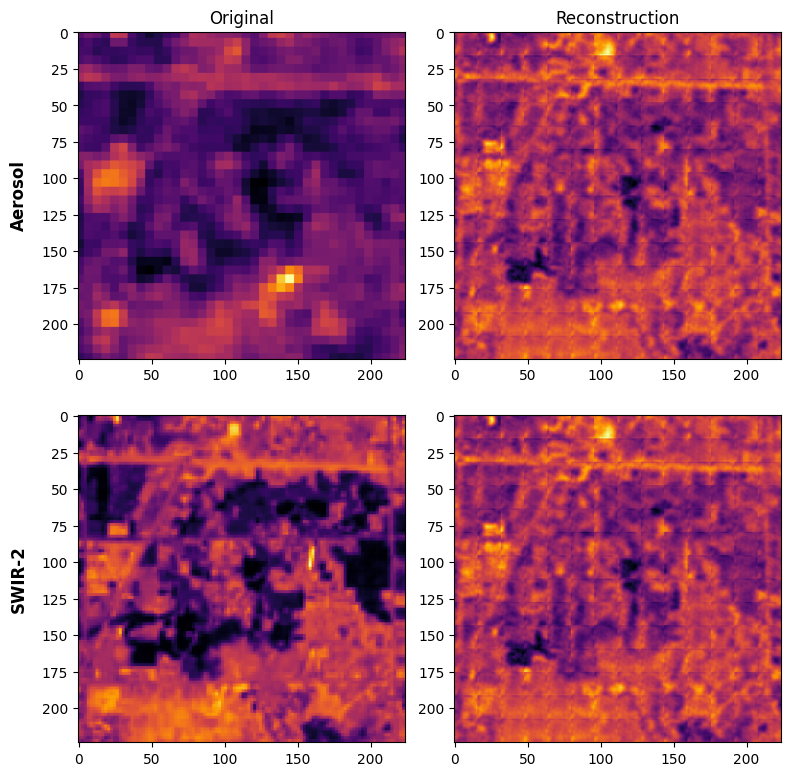

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

ax[0,0].imshow(img[0].cpu().numpy(), cmap='inferno')
ax[0,1].imshow(recon[0][channel_idx_mask[0]].detach().cpu().numpy(), cmap='inferno')   # [0] added

ax[1,0].imshow(img[11].cpu().numpy(), cmap='inferno')
ax[1,1].imshow(recon[0][channel_idx_mask[1]].detach().cpu().numpy(), cmap='inferno')


# Row labels on the left axis — outside the image
ax[0, 0].set_ylabel('Aerosol', fontsize=12, fontweight='bold', labelpad=10)
ax[1, 0].set_ylabel('SWIR-2', fontsize=12, fontweight='bold', labelpad=10)

# Column titles on top row
ax[0, 0].set_title('Original', fontsize=12)
ax[0, 1].set_title('Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()

# Remove ticks but keep labels
for a in ax.flat:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout(pad=1.5)
fig.savefig('reconstructions.pdf', dpi=300, bbox_inches='tight')

### **7. Reconstruction of a fully masked niches image**

In [ ]:
niche_mask = torch.zeros_like(mask)
print(niche_mask.shape)
# apply same mask to all channels of the same sample
# cut the image in four and mask one quarter (e.g., top-left)

niche_mask[:, :7, :7] = True  # mask top-left quarter on every channel

In [ ]:
with torch.amp.autocast(device_type='cuda'):
        output = model.forward(
            multiplex=[img],
            channel_ids=[channel_idx],
            multiplex_mask=[niche_mask],
            sensor_ids=[sensor_idx],
            projection_indices=[proj_idx],
        )
recon = output.decoded_multiplex

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(img[channel_idx_mask].cpu().numpy(), cmap='inferno')
for i in range(niche_mask.shape[1]):
    for j in range(niche_mask.shape[2]):
        if niche_mask[channel_idx_mask,i,j]:
            ax[0].add_patch(plt.Rectangle((j*16, i*16), 16, 16, color='white'))
ax[0].set_title('Masked Input')

ax[1].imshow(recon[0][channel_idx_mask].detach().cpu().numpy(), cmap='inferno')
ax[1].set_title('Reconstruction')
ax[2].imshow(img[channel_idx_mask].cpu().numpy(), cmap='inferno')
ax[2].set_title('Original Crop')

#### **7. Reconstruction of RGB channels**

In [ ]:
channels_mask = [3, 2, 1]


masks = generate_channel_mask(C, H, W, patch_size, channels=channels_mask).cuda()
with torch.amp.autocast(device_type='cuda'):
        output = model_mlp.forward(
            multiplex=[img.cuda()],
            channel_ids=[channel_idx.cuda().long()],
            multiplex_mask=[masks.cuda()],
            sensor_ids=[sensor_idx.cuda().long()],
            projection_indices=[proj_idx.cuda().long()],
        )
recon = output.decoded_multiplex

In [ ]:
transform_rgb(recon[0][channels_mask].detach().cpu().numpy())

In [ ]:
# --- RGB plot of the reconstruction from the masked forward pass ---
recon_img = recon[0].detach().float().cpu()        # [C, H, W]
bands_rgb = [3, 2, 1]                               # red, green, blue (S2L2A, 0-indexed)

mean = torch.tensor(statistics["mean"]["S2L2A"])[bands_rgb].view(-1, 1, 1)
std  = torch.tensor(statistics["std"]["S2L2A"])[bands_rgb].view(-1, 1, 1)

# denormalize -> original scale -> HWC
recon_rgb = (recon_img[bands_rgb]            * std + mean).permute(1, 2, 0).numpy()
gt_rgb    = (img.detach().float().cpu()[bands_rgb] * std + mean).permute(1, 2, 0).numpy()

# same contrast stretch used for the original image earlier in the notebook
recon_vis = transform_rgb(recon_rgb)
gt_vis    = transform_rgb(gt_rgb)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gt_vis);    ax[0].set_title("Original RGB");                       ax[0].axis("off")
ax[1].imshow(recon_vis); ax[1].set_title("Reconstructed RGB (R,G,B masked)");  ax[1].axis("off")
plt.tight_layout()
plt.show()